#Kütüphaneler

In [21]:
!pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 1.0/101.7 MB 5.4 MB/s eta 0:00:19
   - -------------------------------------- 3.9/101.7 MB 9.9 MB/s eta 0:00:10
   --- ------------------------------------ 7.9/101.7 MB 13.3 MB/s eta 0:00:08
   ---- ----------------------------------- 11.5/101.7 MB 14.7 MB/s eta 0:00:07
   ----- ---------------------------------- 14.9/101.7 MB 15.4 MB/s eta 0:00:06
   ------- -------------------------------- 19.7/101.7 MB 16.5 MB/s eta 0:00:05
   --------- ------------------------------ 23.1/101.7 MB 16.5 MB/s eta 0:00:05
   ---------- ----------------------------- 27.0/101.7 MB 17.3 MB/s eta 0:00:05
   ------------ --------------------------- 31.5/101.7 MB 17.9 MB/s eta 0:00:04
   -------------- ------------------------- 35.9/101.7 MB 17.9 MB/s eta 0:00:04
   --------------- ------------------------ 39.3/101.7 MB 18.0 

In [60]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix, roc_curve, auc
from sklearn.linear_model import LogisticRegression
import shap


SORU 1

1. Veri Setinin Yüklenmesi
1.1 scikit-learn’den Veri Seti Yükleme
Kullanılabilecek veri setleri:
•	Breast Cancer Wisconsin
•	Wine Classification

Wine Classification dataset üzerinde çalışılacak

In [3]:
# Veri setini yükle
wine_data = load_wine()

SORU 1

1.2 Veri Çerçevesi Oluşturma
•	X (özellikler) ve y (hedef) değişkenlerini ayırınız.
•	pandas DataFrame formatına dönüştürünüz.
•	İlk 5 satırı görüntüleyiniz.

In [71]:
# X (Özellikler) ve y (Hedef) değişkenlerini oluşturma
X = pd.DataFrame(wine_data.data, columns=wine_data.feature_names)
y = pd.Series(wine_data.target, name='target')

# İlk 5 satırı görüntüleme
print("Veri Setinin İlk 5 Satırı:")
print(X.head())
print("\nVeri setinin boyutu:", X.shape)



# 1. Benzersiz sınıf numaralarını görüntüleme (0, 1, 2)
unique_classes = np.unique(y)
print(f"\nHedef değişkendeki benzersiz değerler: {unique_classes}")

# 2. Bu numaraların hangi şarap türlerine karşılık geldiğini görme
class_names = wine_data.target_names
for i, name in enumerate(class_names):
    print(f"Sınıf {i}: {name}")

# 3. Her sınıftan kaçar adet örnek olduğunu görme (Sınıf dengesi kontrolü)
print("\nSınıf Dağılımı:")
print(y.value_counts())

Veri Setinin İlk 5 Satırı:
   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   od280/od315_of_diluted_wines  pr

YORUM 1

Wine veri sati 178 satır,13 farklı özellikten(alcohol, malic_acid, ash vb.) sütundan oluşuyor. Y hedef değişken 3 farklı sınıf yani şarap türüne ait numara(0,1,2) alabiliyor. Şarap türleri(sınıflar) ve dağılımları; class_0:59, class_1:71, class_2:48. Sınıflar nispeten dengeli bir yapıya sahip. Bu nedenle modelin bir sınıfa daha çok yatkınlık gösterme riski yani bias ı düşük.

SORU 2

2. Veri Seti Kalite Kontrolleri
2.1 Eksik Değer Analizi
•	Her sütunda missing value kontrolü yapınız.
•	Eksik değer varsa uygun doldurma yöntemi (mean/median) uygulayınız.

In [5]:
# Her sütundaki eksik değer sayısını kontrol etme
missing_values = X.isnull().sum()
print("Eksik Değer Sayıları:")
print(missing_values)

Eksik Değer Sayıları:
alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
dtype: int64


YORUM 1

Hiç bir sütunda missing value bulunmamaktadır. Bu nedenle doldurma işlemi yapılmayacaktır.

SORU 2

2.2 Aykırı Değer (Outlier)Analizi

Aşağıdaki yöntemlerden en az

birini kullanınız:

·       IQR yöntemi

·       Z-score yöntemi

·       Boxplot analizi

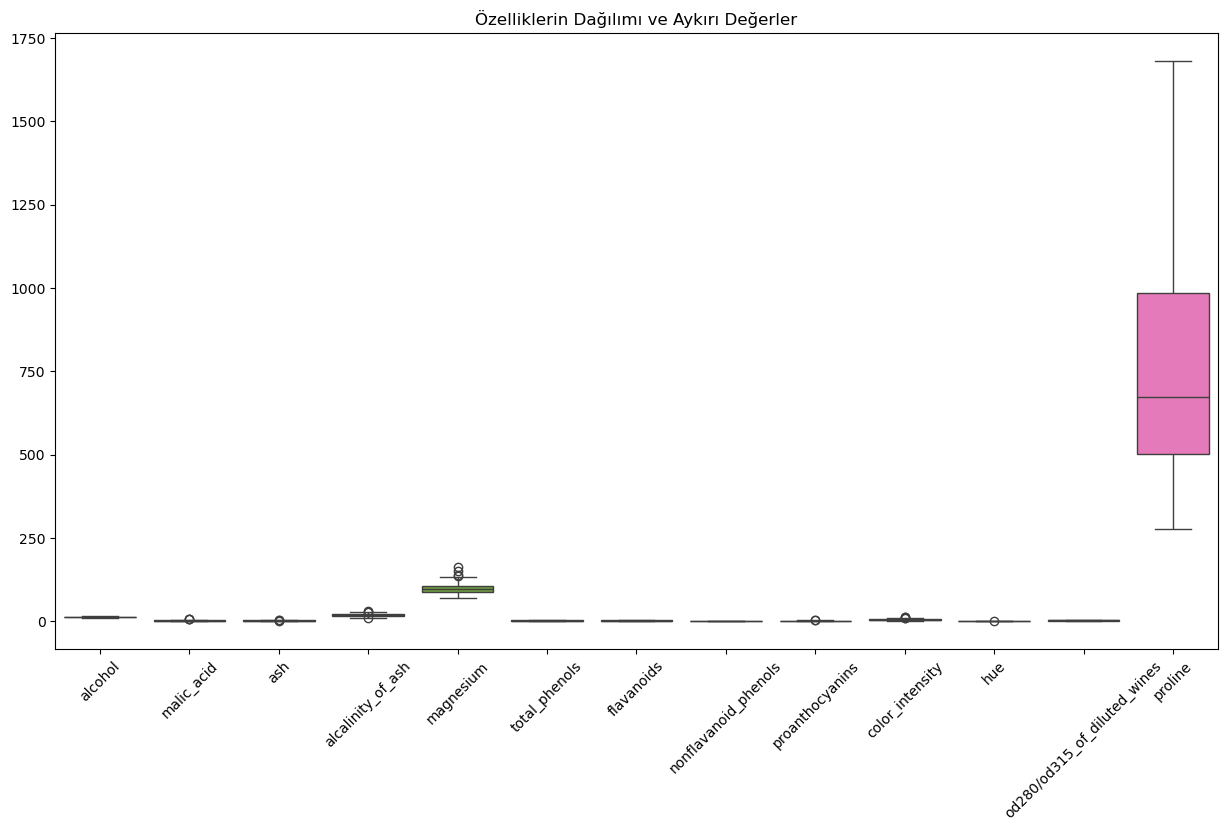

In [6]:
plt.figure(figsize=(15, 8))
sns.boxplot(data=X)
plt.xticks(rotation=45)
plt.title("Özelliklerin Dağılımı ve Aykırı Değerler")
plt.show()

YORUM 2

Wine veri setindeki özelliklerin dağılımını anlamak için görsel yöntem olan Boxplot (Kutu Grafiği) analizini yapıldı. Bu grafikte en belirgin özellik, proline satırının 250-1750 aralığında değer alması olmuştur. Bu durum modeli şaşırtabilir ve proline satırına daha çok önem verebilir. Bu nedenle ölçeklendirme yapılması gerekmektedir. Diğer satırlarda çok belirgin bir farklılık görülmemektedir.

YORUM 2

Boxplot ardından sayısal bir eşik belirlemek için IQR (Interquartile Range) yöntemi kullanıldı.

In [7]:
def detect_outliers_iqr(df):
    outliers_info = {}
    for col in df.columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        # Sınırların dışında kalanları bul
        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
        if not outliers.empty:
            outliers_info[col] = len(outliers)
            
    return outliers_info

outlier_counts = detect_outliers_iqr(X)
print("Aykırı Değer İçeren Sütunlar ve Sayıları:")
print(outlier_counts)

Aykırı Değer İçeren Sütunlar ve Sayıları:
{'malic_acid': 3, 'ash': 3, 'alcalinity_of_ash': 4, 'magnesium': 4, 'proanthocyanins': 2, 'color_intensity': 4, 'hue': 1}


YORUM 2

Wine veri seti 178 satırdan oluşuyor. Toplam aykırı değer sayımız 21. Bu durum veri setinin %12,5 luk kısmına denk geliyor. Sütun bazlı düşündüğümüzde her bir sütunda ise yaklaşık 1-4 aralığında aykırı değer var demektir. Bu da sütunlar için veri setinin %2-3 lük kısmını oluşturmaktadır. Bu düşük bir sayıdır. Boxplot analizine de baktığımızda bu aykırı değerler çok uçuk farklar yaratacak boyuttaki değerler değil. Bu nedenle bu verilerden vazgeçmek yerine bu verileri korumak daha uygun olacaktır.

SORU 2

Aykırı değerlerin modele etkisini kısa açıklayınız.
2.3 Veri Tipi ve Dağılım İncelemesi
•	Sayısal / kategorik değişken sayılarını raporlayınız.
•	Her sütunun dtype bilgisini gösteriniz.

In [8]:
# Her sütunun dtype bilgisini görüntüleme
print("Veri Tipleri Bilgisi:")
print(X.dtypes)

# Sayısal ve kategorik değişken sayılarını raporlama
num_cols = X.select_dtypes(include=['float64', 'int64']).columns
cat_cols = X.select_dtypes(include=['object', 'category']).columns

print(f"\nSayısal Değişken Sayısı: {len(num_cols)}")
print(f"Kategorik Değişken Sayısı: {len(cat_cols)}")

Veri Tipleri Bilgisi:
alcohol                         float64
malic_acid                      float64
ash                             float64
alcalinity_of_ash               float64
magnesium                       float64
total_phenols                   float64
flavanoids                      float64
nonflavanoid_phenols            float64
proanthocyanins                 float64
color_intensity                 float64
hue                             float64
od280/od315_of_diluted_wines    float64
proline                         float64
dtype: object

Sayısal Değişken Sayısı: 13
Kategorik Değişken Sayısı: 0


YORUM 2

Wine veri seti tamamen sayısal verilerden oluşmaktadır. Kategorik veri bulunmamaktadır.

SORU 3

3. Keşifsel Veri Analizi (EDA)
3.1 İstatistiksel Özellikler
Her özellik için:
•	Mean
•	Median
•	Min–Max
•	Std
•	Q1–Q3

In [9]:
# Temel istatistiksel özet (Mean, Std, Min, Q1, Q2(Median), Q3, Max)
eda_summary = X.describe().T

# Median (Q2) değerini netleştirmek ve Q1-Q3 farkını görmek için düzenleme
eda_summary['median'] = X.median()
eda_summary = eda_summary[['mean', 'median', 'std', 'min', 'max', '25%', '75%']]

# Sütun isimlerini daha okunur hale getirelim
eda_summary.columns = ['Mean', 'Median', 'Std', 'Min', 'Max', 'Q1', 'Q3']

print(eda_summary)

                                    Mean   Median         Std     Min  \
alcohol                        13.000618   13.050    0.811827   11.03   
malic_acid                      2.336348    1.865    1.117146    0.74   
ash                             2.366517    2.360    0.274344    1.36   
alcalinity_of_ash              19.494944   19.500    3.339564   10.60   
magnesium                      99.741573   98.000   14.282484   70.00   
total_phenols                   2.295112    2.355    0.625851    0.98   
flavanoids                      2.029270    2.135    0.998859    0.34   
nonflavanoid_phenols            0.361854    0.340    0.124453    0.13   
proanthocyanins                 1.590899    1.555    0.572359    0.41   
color_intensity                 5.058090    4.690    2.318286    1.28   
hue                             0.957449    0.965    0.228572    0.48   
od280/od315_of_diluted_wines    2.611685    2.780    0.709990    1.27   
proline                       746.893258  673.500  

YORUM 3

Wine veri setinde alcohol, ash, alcalinity_of_ash, total_phenols, flavanoids, nonflavanoid_phenols, proanthocyanins, hue, od280/od315_of_diluted_wines sütunlarının ortalama ve medyan değerleri birbirine yakın olduğu için normal dağılıma sahip veriler var diyebiliriz. Ancak proline gibi ortalama ve medyan arasındaki büyük fark ve ortalamanın medyandan büyük olması verinin sağa kuyruklu olduğunu göstermektedir. Bu veri setinde standardizasyon yapılması şarttır.

SORU 3

3.2 Korelasyon Matrisi
•	Pearson korelasyon matrisi oluşturunuz.
•	Isı haritası (heatmap) ile görselleştiriniz.
•	En yüksek korelasyonlu 3 çift özelliği yorumlayınız.

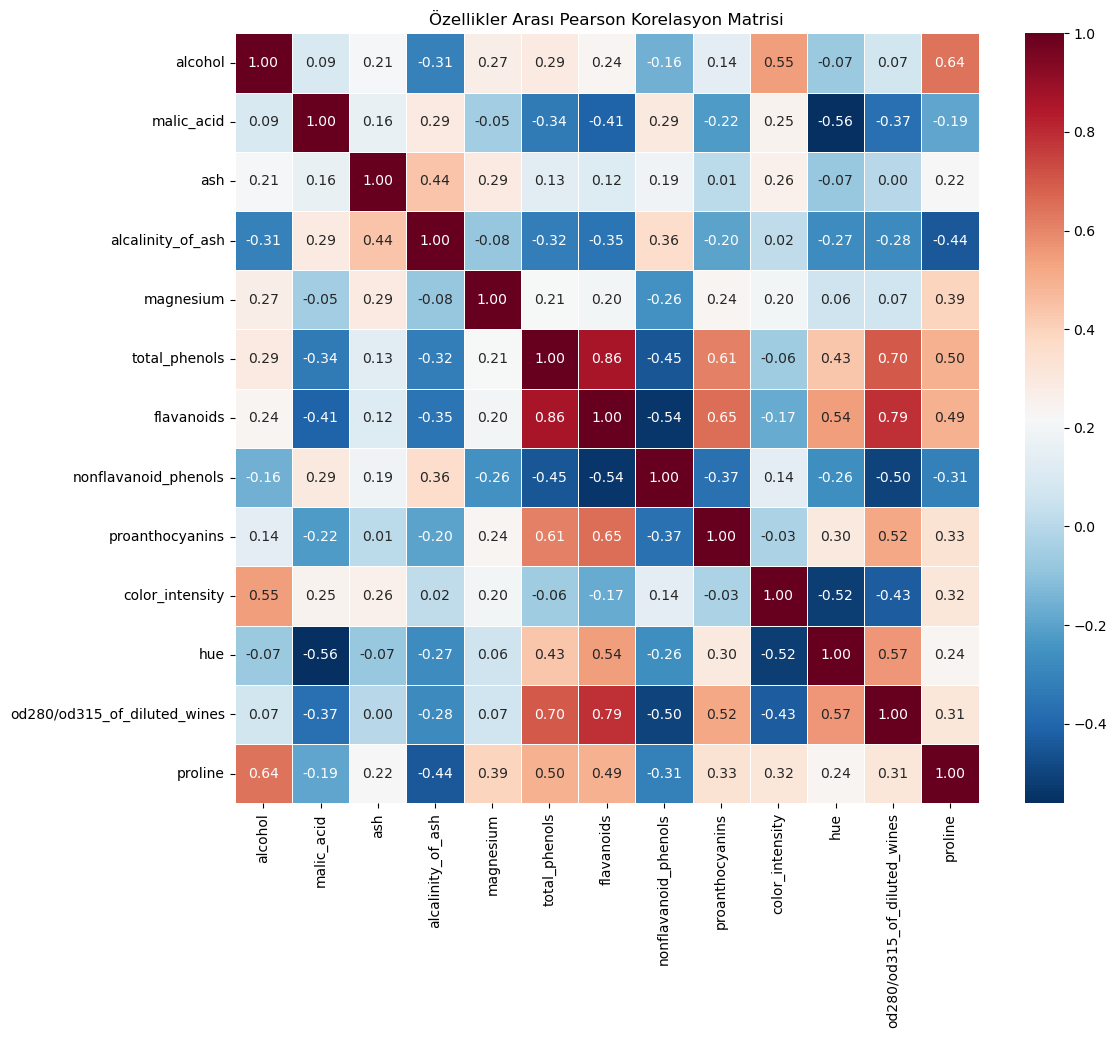

In [10]:
# Pearson korelasyon matrisini hesapla
corr_matrix = X.corr()

# Isı haritasını çizdir
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', fmt='.2f', linewidths=0.5)
plt.title("Özellikler Arası Pearson Korelasyon Matrisi")
plt.show()

YORUM 3

Görseldeki verilere dayanarak en yüksek korelasyona sahip 3 çiftin analizi:

1. Total Phenols & Flavanoids (0.86)
Çok Güçlü Pozitif ilişkiye sahiptirler ve grafikteki en yüksek değerdir. Bu iki değişken modele neredeyse aynı bilgiyi sağlar. 

2. Flavanoids & od280/od315_of_diluted_wines (0.79)
Güçlü Pozitif ilişkiye sahiptirler.

3. Total Phenols & od280/od315_of_diluted_wines (0.70)
Güçlü Pozitif ilişkiye sahiptirler.

SORU 3

3.3 Boxplot Analizi
•	Her özellik için boxplot çiziniz.
•	Aykırı değer eğilimlerini yorumlayınız.

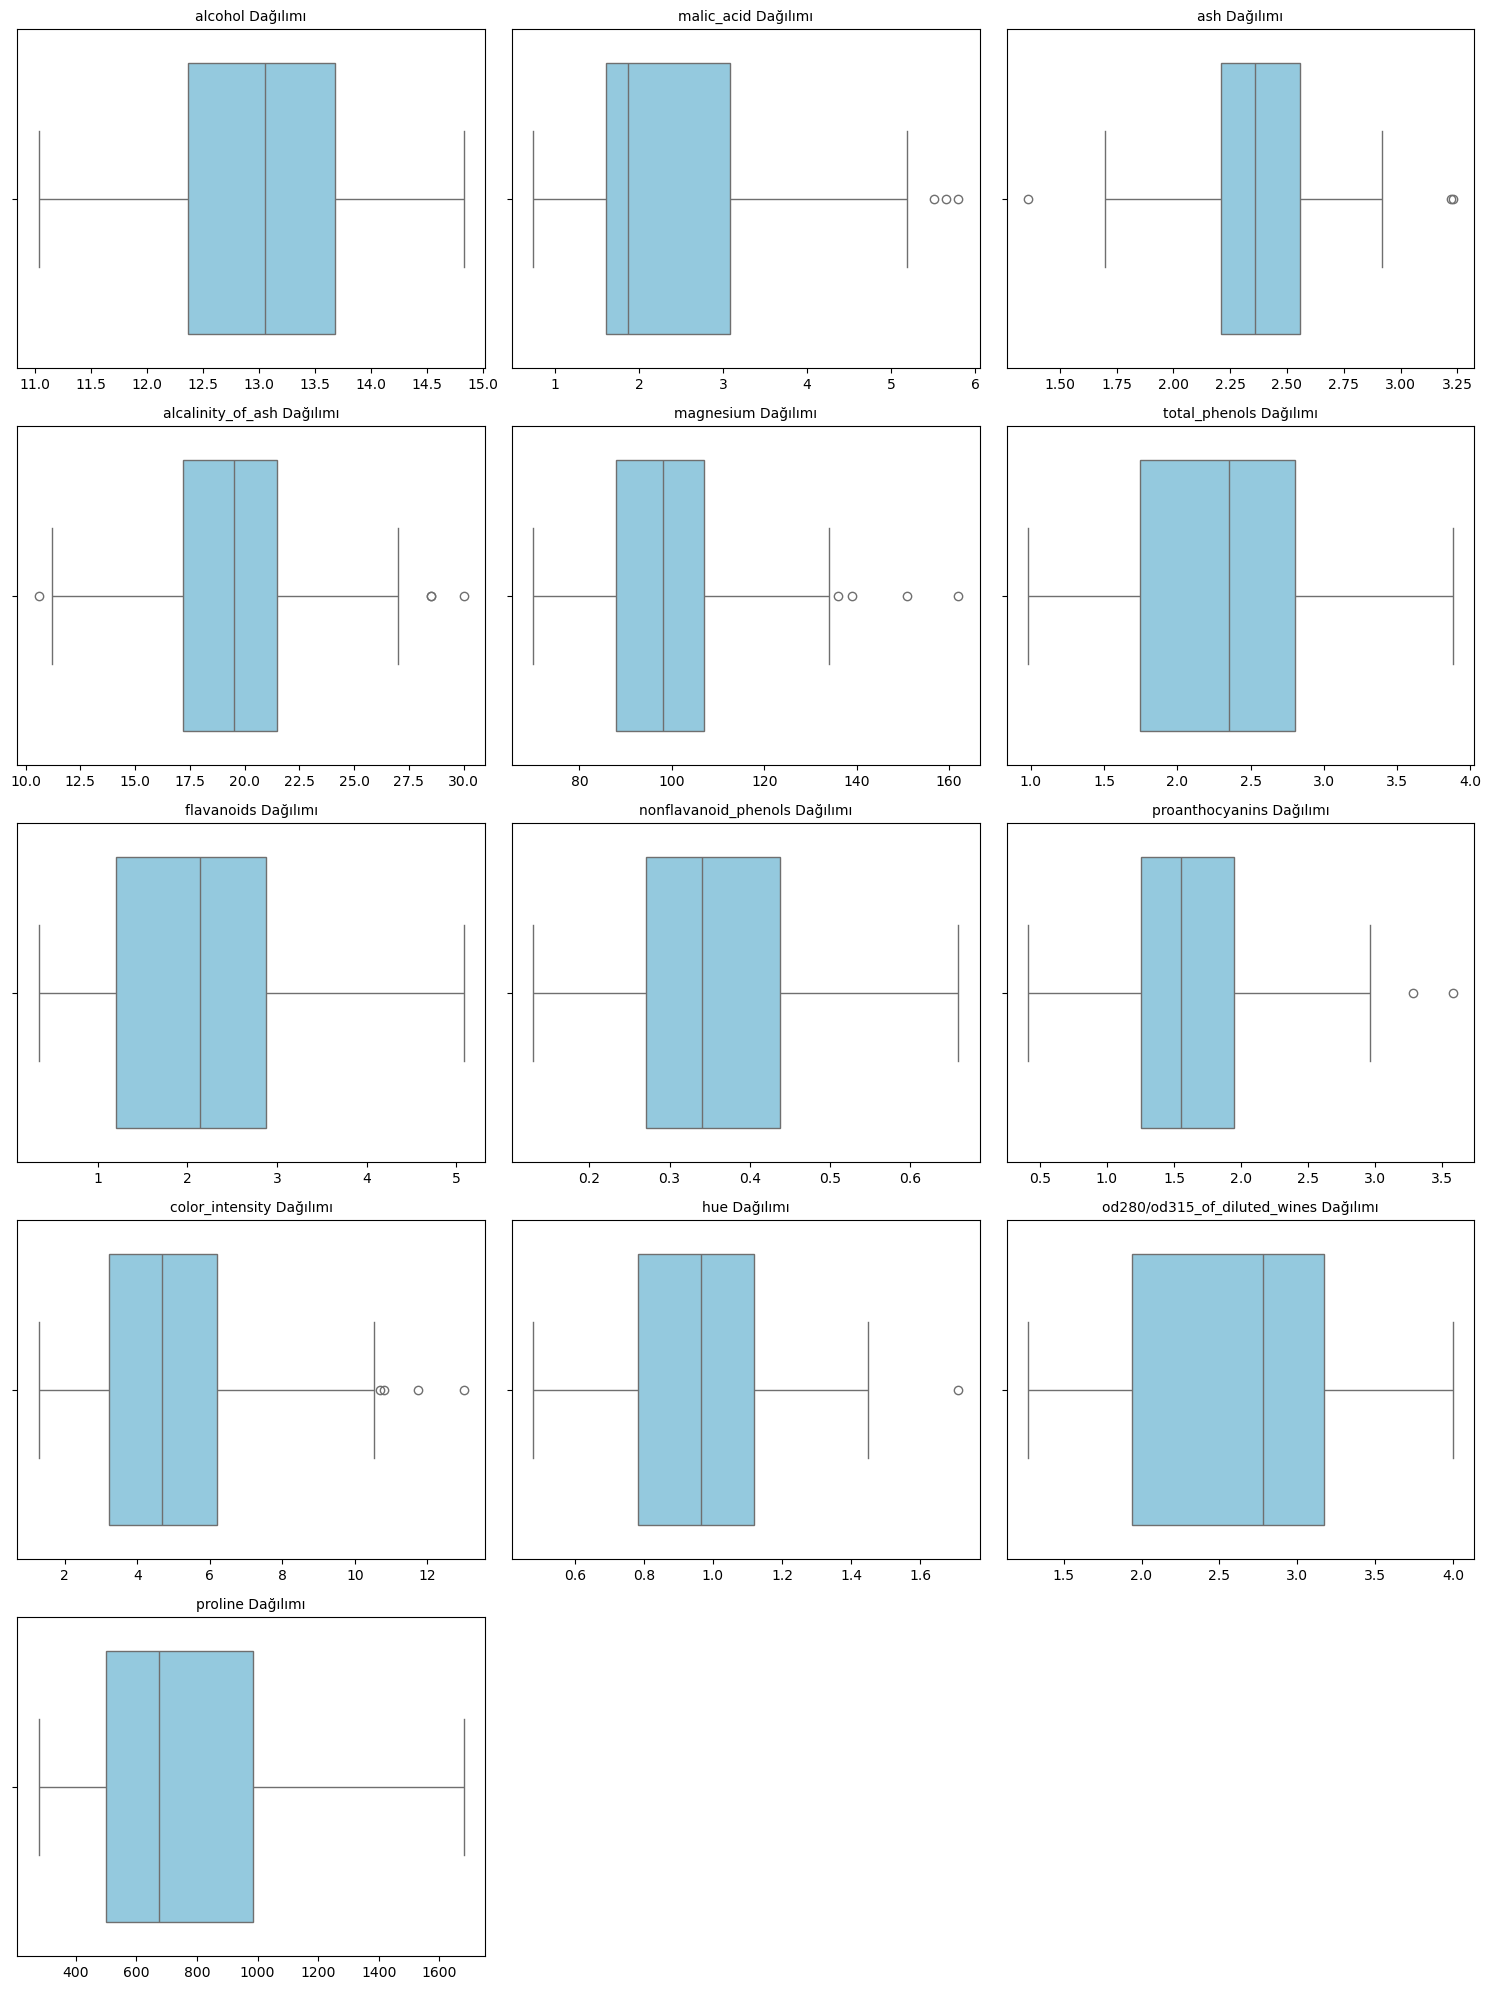

In [11]:
# Özellik sayısına göre bir grid oluşturalım (13 özellik için 4x4 veya 5x3)
fig, axes = plt.subplots(nrows=5, ncols=3, figsize=(15, 20))
axes = axes.flatten()

# Her sütun için ayrı boxplot çizimi
for i, col in enumerate(X.columns):
    sns.boxplot(x=X[col], ax=axes[i], color='skyblue')
    axes[i].set_title(f'{col} Dağılımı', fontsize=10)
    axes[i].set_xlabel('')

# Boş kalan subplotları kapatalım
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

YORUM 3

Aykırı Değer Eğilim Analizi

Pozitif Yönlü (Üst Sınır) Sapmalar: malic_acid, magnesium, color_intensity ve proanthocyanins grafiklerinde, sağ taraftaki "bıyık" (whisker) çizgisinin ilerisinde küçük yuvarlak daireler görülüyor. Bu durum bazı satırların beklenenden daha yüksek değerler ürettiğini göstermektedir.

Negatif Yönlü ve Çift Taraflı Sapmalar: ash ve alcalinity_of_ash grafiklerinde hem negatif hem de pozitif değerlerde aykırı noktalar mevcut.

Aykırı Değeri Olmayan "Temiz" Değişkenler: alcohol, total_phenols, flavanoids, nonflavanoid_phenols, od280/od315 ve proline grafiklerinde hiçbir aykırı değer noktası bulunmuyor. Bu özellikler oldukça kararlı bir dağılım sergilemektedir. 

Genel Değerlendirme: Aykırı değerler veri setinin genelini domine etmiyor; sadece belirli özelliklerde ortaya çıkıyor. Bu, veri setinin kaliteli olduğunu göstermektedir.

SORU 4

4. Veri Setinin Bölünmesi
Veriyi aşağıdaki oranlarda bölünüz:
•	%70 Training
•	%10 Validation
•	%20 Test
Not: Validation için ikinci bir train_test_split yapılabilir.

In [12]:
# 1. Adım: Veriyi %80 Eğitim+Validation ve %20 Test olarak ayırıyoruz
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# 2. Adım: %80'lik kısmı kendi içinde %70 Training ve %10 Validation olacak şekilde bölüyoruz
# (0.10 / 0.80 = 0.125 oranı %10'luk tüm veri setine karşılık gelir)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.125, random_state=42, stratify=y_train_val
)

print(f"Toplam Veri Sayısı: {len(X)}")
print(f"Training Seti (%70): {len(X_train)}")
print(f"Validation Seti (%10): {len(X_val)}")
print(f"Test Seti (%20): {len(X_test)}")

Toplam Veri Sayısı: 178
Training Seti (%70): 124
Validation Seti (%10): 18
Test Seti (%20): 36


SORU 5

5. Veri Ölçeklendirme (Scaling)
Aşağıdaki scaler'lardan biri kullanılacaktır:
•	StandardScaler (önerilen)
•	MinMaxScaler
•	RobustScaler
Ölçeklendirilmiş veriyi X_scaled olarak kaydediniz.

In [13]:
# 1. Scaler nesnesini oluşturma
scaler = StandardScaler()

# 2. Sadece eğitim verisi ile istatistikleri (mean, std) öğren ve uygula
X_train_scaled = scaler.fit_transform(X_train)

# 3. Öğrenilen istatistikleri Validation ve Test setlerine uygula
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Ödevde istendiği üzere birleşik bir X_scaled (görselleştirme veya PCA öncesi için)
X_scaled = scaler.fit_transform(X)

print("Ölçeklendirme sonrası ilk satır örneği:")
print(X_train_scaled[0])

Ölçeklendirme sonrası ilk satır örneği:
[-0.01751449  1.08917778 -0.04011736 -0.30840546  0.43322425 -1.34250465
 -1.32227476  0.35266762 -1.11763857  0.12583729 -1.22675399 -1.22364572
 -0.20937508]


SORU 6

6. Özellik Seçimi ve Boyut İndirgeme
Bu bölümün sonunda üç farklı veri temsili oluşturmanız zorunludur:
   1.	Ham veri (sadece preprocessing yapılmış)
   2.	PCA ile indirgenmiş veri
   3.	LDA ile indirgenmiş veri

In [14]:
# 1.	Ham veri (sadece preprocessing yapılmış)
# 1. Ölçeklendirici nesnesini tanımlıyoruz
scaler = StandardScaler()

# 2. Eğitim verisi üzerinden istatistikleri öğreniyoruz ve eğitim verisini dönüştürüyoruz
X_train_scaled = scaler.fit_transform(X_train)

# 3. Aynı istatistikleri (mean ve std) kullanarak Test ve Validation verilerini dönüştürüyoruz
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Kontrol için boyut bilgisini yazdıralım
print(f"Ham Veri (Scaled) Eğitim boyutu: {X_train_scaled.shape}")
print(f"Ham Veri (Scaled) Validation boyutu: {X_val_scaled.shape}")
print(f"Ham Veri (Scaled) Test boyutu: {X_test_scaled.shape}")

Ham Veri (Scaled) Eğitim boyutu: (124, 13)
Ham Veri (Scaled) Validation boyutu: (18, 13)
Ham Veri (Scaled) Test boyutu: (36, 13)


In [26]:
# 2.	PCA ile indirgenmiş veri
# Verinin %95 varyansını koruyacak şekilde PCA uygula
pca = PCA(n_components=2) # Görselleştirme kolaylığı için 2 bileşen
X_train_pca = pca.fit_transform(X_train_scaled)
X_val_pca = pca.transform(X_val_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(f"PCA sonrası özellik sayısı: {X_train_pca.shape[1]}")
print(f"Açıklanan Toplam Varyans: {pca.explained_variance_ratio_.sum():.2f}")

PCA sonrası özellik sayısı: 2
Açıklanan Toplam Varyans: 0.56


In [27]:
# 3.	LDA ile indirgenmiş veri
# Sınıf sayısı 3 olduğu için LDA en fazla (3-1) = 2 bileşen oluşturabilir
lda = LDA(n_components=2)
X_train_lda = lda.fit_transform(X_train_scaled, y_train)
X_val_lda = lda.transform(X_val_scaled)
X_test_lda = lda.transform(X_test_scaled)

print(f"LDA sonrası özellik sayısı: {X_train_lda.shape[1]}")

LDA sonrası özellik sayısı: 2


YORUM 6

PCA, sınıflardan bağımsız olarak verideki en büyük "değişimi" yakalamaya çalışırken; LDA doğrudan sınıfları birbirinden en iyi ayıracak "yönleri" bulur. 13 farklı kimyasal özelliği sadece 2 boyuta indirgedik. PCA ile verinin varyansının önemli bir kısmını korurken, LDA ile sınıf ayrıştırılabilirliğini optimize ettik.

SORU 6

6.1 PCA (Principal Component Analysis)
•	PCA uygulayınız.
•	Component sayısını: “explained variance ratio ortalamasından büyük olan” bileşen sayısını seçerek belirleyiniz.
•	Explained variance grafiğini çiziniz.
•	Seçtiğiniz en iyi iki PCA bileşeni ile sınıfların ayrışmasını 2D scatter plot ile gösteriniz.

Bileşen Varyans Oranları: [0.36480935 0.19375929 0.11323704 0.07272637 0.05929801 0.04761771
 0.04503476 0.02479491 0.02336713 0.01818575 0.01750167 0.0126753
 0.00699272]
Varyans Ortalaması: 0.0769
Kurala göre seçilen bileşen sayısı: 3


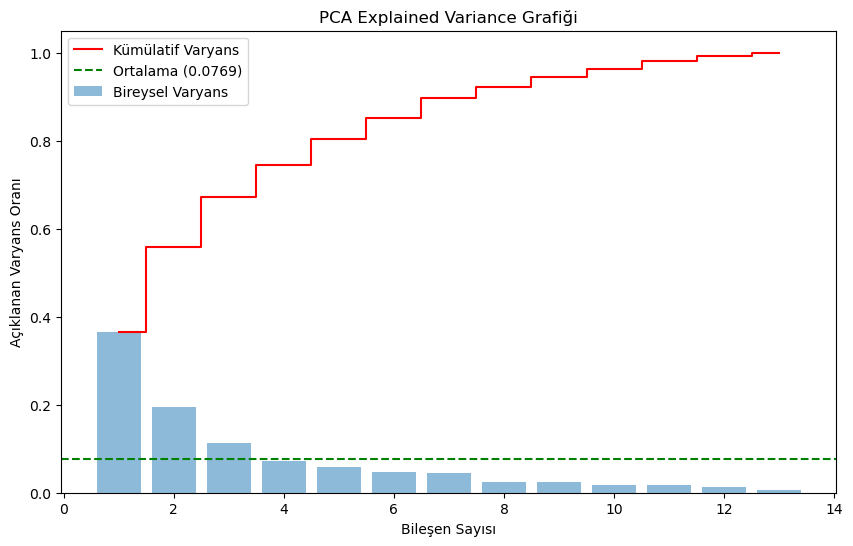

In [28]:
# Önce tüm bileşenler için (13 özellik) PCA fit edelim
pca_full = PCA()
pca_full.fit(X_train_scaled)

# Varyans oranlarını ve ortalamayı hesaplayalım
exp_var_ratio = pca_full.explained_variance_ratio_
mean_var = np.mean(exp_var_ratio)

# Kurala uyan bileşenleri seçme: Ortalama varyans oranından büyük olanlar
n_components = np.sum(exp_var_ratio > mean_var)

print(f"Bileşen Varyans Oranları: {exp_var_ratio}")
print(f"Varyans Ortalaması: {mean_var:.4f}")
print(f"Kurala göre seçilen bileşen sayısı: {n_components}")

# Grafiği çizelim (Scree Plot)
plt.figure(figsize=(10, 6))
plt.bar(range(1, 14), exp_var_ratio, alpha=0.5, align='center', label='Bireysel Varyans')
plt.step(range(1, 14), np.cumsum(exp_var_ratio), where='mid', label='Kümülatif Varyans', color='red')
plt.axhline(y=mean_var, color='green', linestyle='--', label=f'Ortalama ({mean_var:.4f})')
plt.ylabel('Açıklanan Varyans Oranı')
plt.xlabel('Bileşen Sayısı')
plt.legend(loc='best')
plt.title('PCA Explained Variance Grafiği')
plt.show()

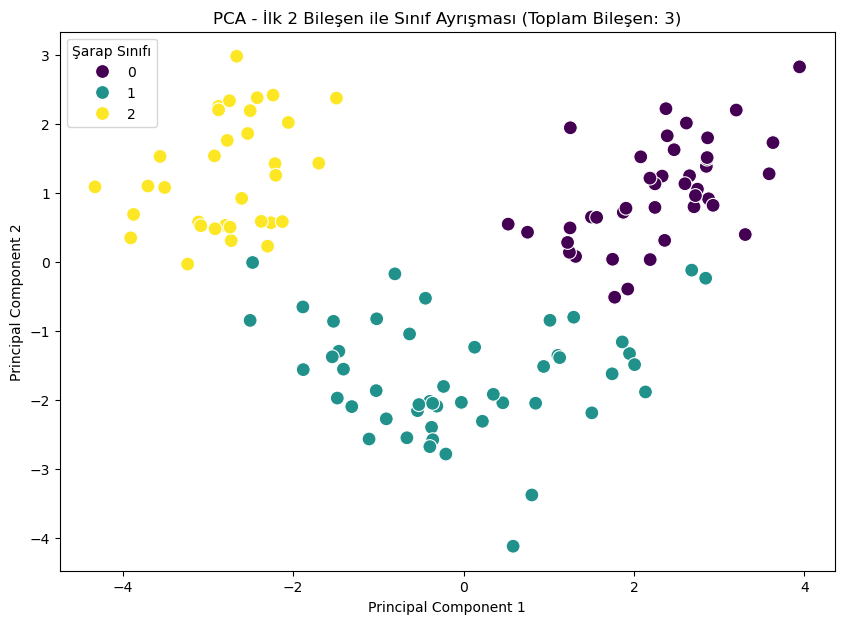

In [44]:
# Belirlenen n_components ile PCA uygula
pca_final = PCA(n_components=n_components)
X_train_pca = pca_final.fit_transform(X_train_scaled)
X_val_pca = pca_final.transform(X_val_scaled)
X_test_pca = pca_final.transform(X_test_scaled)

# 2D Scatter Plot (İlk iki bileşen ile)
plt.figure(figsize=(10, 7))
sns.scatterplot(x=X_train_pca[:, 0], y=X_train_pca[:, 1], hue=y_train, palette='viridis', s=100)
plt.title(f'PCA - İlk 2 Bileşen ile Sınıf Ayrışması (Toplam Bileşen: {n_components})')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Şarap Sınıfı')
plt.show()

SORU 6

6.2 LDA (Linear Discriminant Analysis)
•	LDA uygulayınız.
•	n_components = 3 olarak seçiniz.
•	İlk iki LDA bileşeniyle sınıflar arası ayrımı 2D scatter plot ile görselleştiriniz.

In [40]:
# LDA Uygulama (n_components kısıtı nedeniyle en fazla 2 üretilir)
lda = LDA(n_components=2) 
X_train_lda = lda.fit_transform(X_train_scaled, y_train)
X_val_lda = lda.transform(X_val_scaled)
X_test_lda = lda.transform(X_test_scaled)

print(f"LDA sonrası elde edilen bileşen sayısı: {X_train_lda.shape[1]}")

LDA sonrası elde edilen bileşen sayısı: 2


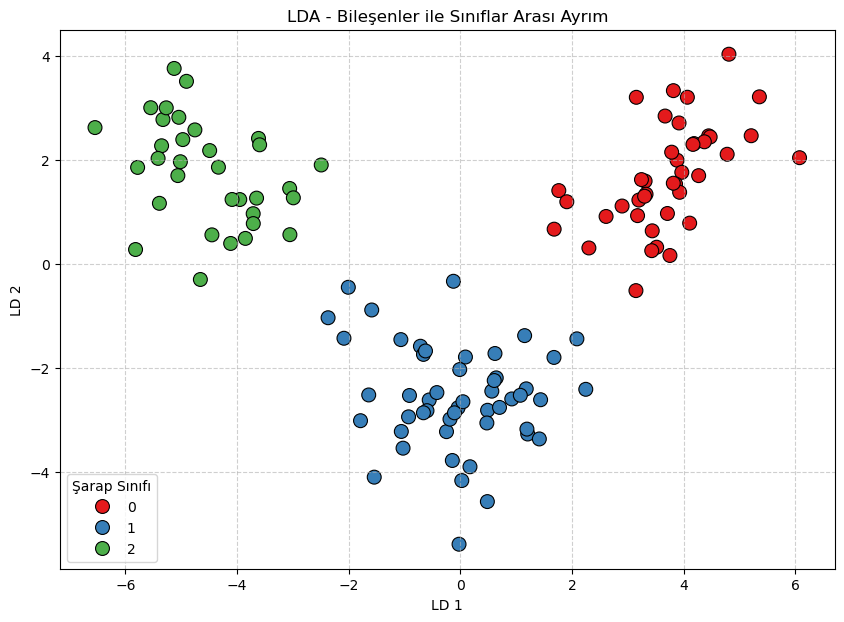

In [41]:
plt.figure(figsize=(10, 7))
sns.scatterplot(x=X_train_lda[:, 0], y=X_train_lda[:, 1], hue=y_train, palette='Set1', s=100, edgecolor='black')
plt.title('LDA - Bileşenler ile Sınıflar Arası Ayrım')
plt.xlabel('LD 1')
plt.ylabel('LD 2')
plt.legend(title='Şarap Sınıfı')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

SORU 7

7. Makine Öğrenmesi Modellerinin Kurulması
Aşağıdaki 5 algoritma, her üç veri temsiliyle ayrı ayrı eğitilecektir:
1.	Logistic Regression
2.	Decision Tree Classifier
3.	Random Forest Classifier
4.	XGBoost Classifier
5.	Naive Bayes (GaussianNB)
Toplamda 15 farklı model eğitilecektir:
•	5 model × Ham veri
•	5 model × PCA verisi
•	5 model × LDA verisi
Her model için validation seti üzerinde performans hesaplanacaktır.

In [55]:
# 1. Veri Temsillerinin Tanımlanması
# (Önemli: PCA ve LDA verilerinin 2 özellikli olduğundan emin olun)
data_representations = {
    "Ham Veri (Scaled)": (X_train_scaled, X_val_scaled),
    "PCA Verisi": (X_train_pca, X_val_pca),
    "LDA Verisi": (X_train_lda, X_val_lda)
}

results = []

# 2. Eğitim ve Performans Hesaplama Döngüsü
for data_name, (train_data, val_data) in data_representations.items():
    
    # --- DÜZELTME: Modelleri her veri döngüsünün başında SIFIRDAN tanımlıyoruz ---
    # Bu sayede her model, giriş boyutuna (13, 3 veya 2 özellik) göre yeniden şekillenir.
    current_models = {
        "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
        "Decision Tree": DecisionTreeClassifier(random_state=42),
        "Random Forest": RandomForestClassifier(random_state=42),
        "XGBoost": XGBClassifier(eval_metric='mlogloss', random_state=42),
        "Naive Bayes": GaussianNB()
    }
    
    for model_name, model in current_models.items():
        # --- EĞİTİM ADIMI ---
        model.fit(train_data, y_train) 
        
        # --- TAHMİN VE ÖLÇÜM ADIMI ---
        y_pred = model.predict(val_data)
        acc = accuracy_score(y_val, y_pred)
        
        results.append({
            "Veri Temsili": data_name,
            "Algoritma": model_name,
            "Validation Accuracy": acc
        })

# 3. Sonuçları Tablo Haline Getirme
results_df = pd.DataFrame(results)
pivot_results = results_df.pivot(index='Algoritma', columns='Veri Temsili', values='Validation Accuracy')

# Sonuçları daha okunaklı yazdırmak için
print("\n--- Model Validation Sonuçları ---")
print(pivot_results)


--- Model Validation Sonuçları ---
Veri Temsili         Ham Veri (Scaled)  LDA Verisi  PCA Verisi
Algoritma                                                     
Decision Tree                 0.944444         1.0    0.888889
Logistic Regression           1.000000         1.0    1.000000
Naive Bayes                   1.000000         1.0    1.000000
Random Forest                 1.000000         1.0    1.000000
XGBoost                       1.000000         1.0    0.944444


SORU 8

8. Validation Performanslarının Ölçülmesi
Her model validation setinde aşağıdaki metriklerle değerlendirilecektir:
•	Accuracy
•	Precision
•	Recall
•	F1-score
•	ROC-AUC
Sonuçları tek bir tablo halinde karşılaştırınız.

In [54]:
metrics_list = []

# 1. Veri temsillerini tanımlayalım
data_representations = {
    "Ham Veri (Scaled)": (X_train_scaled, X_val_scaled),
    "PCA Verisi": (X_train_pca, X_val_pca),
    "LDA Verisi": (X_train_lda, X_val_lda)
}

# 2. Ana döngü
for data_name, (train_data, val_data) in data_representations.items():
    
    # KRİTİK DÜZELTME: Modelleri her veri tipi için burada sıfırlıyoruz
    current_models = {
        "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
        "Decision Tree": DecisionTreeClassifier(random_state=42),
        "Random Forest": RandomForestClassifier(random_state=42),
        "XGBoost": XGBClassifier(eval_metric='mlogloss', random_state=42),
        "Naive Bayes": GaussianNB()
    }
    
    for model_name, model in current_models.items():
        # --- ÖNCE EĞİTİM (Fit) ---
        # Bu satır olmazsa model boyutları tanımaz ve hata verir
        model.fit(train_data, y_train)
        
        # --- SONRA TAHMİN (Predict) ---
        y_pred = model.predict(val_data)
        
        # Olasılıkları al (ROC-AUC için)
        if hasattr(model, "predict_proba"):
            y_probs = model.predict_proba(val_data)
        else:
            y_probs = None

        # --- METRİKLERİ HESAPLA ---
        acc = accuracy_score(y_val, y_pred)
        prec = precision_score(y_val, y_pred, average='weighted')
        rec = recall_score(y_val, y_pred, average='weighted')
        f1 = f1_score(y_val, y_pred, average='weighted')
        
        try:
            # Çok sınıflı ROC-AUC (ovr stratejisi)
            if y_probs is not None:
                roc_auc = roc_auc_score(y_val, y_probs, multi_class='ovr')
            else:
                roc_auc = 0.0
        except:
            roc_auc = 0.0

        metrics_list.append({
            "Veri Temsili": data_name,
            "Algoritma": model_name,
            "Accuracy": acc,
            "Precision": prec,
            "Recall": rec,
            "F1-Score": f1,
            "ROC-AUC": roc_auc
        })

# 3. Tabloyu oluştur ve göster
full_results_df = pd.DataFrame(metrics_list)
print("\n--- Tüm Metrikler ve Model Karşılaştırması ---")
print(full_results_df.to_string(index=False))


--- Tüm Metrikler ve Model Karşılaştırması ---
     Veri Temsili           Algoritma  Accuracy  Precision   Recall  F1-Score  ROC-AUC
Ham Veri (Scaled) Logistic Regression  1.000000   1.000000 1.000000  1.000000 1.000000
Ham Veri (Scaled)       Decision Tree  0.944444   0.951389 0.944444  0.943771 0.957071
Ham Veri (Scaled)       Random Forest  1.000000   1.000000 1.000000  1.000000 1.000000
Ham Veri (Scaled)             XGBoost  1.000000   1.000000 1.000000  1.000000 1.000000
Ham Veri (Scaled)         Naive Bayes  1.000000   1.000000 1.000000  1.000000 1.000000
       PCA Verisi Logistic Regression  1.000000   1.000000 1.000000  1.000000 1.000000
       PCA Verisi       Decision Tree  0.888889   0.888889 0.888889  0.888889 0.919372
       PCA Verisi       Random Forest  1.000000   1.000000 1.000000  1.000000 1.000000
       PCA Verisi             XGBoost  0.944444   0.951389 0.944444  0.943210 1.000000
       PCA Verisi         Naive Bayes  1.000000   1.000000 1.000000  1.000000 1.00

LDA Verisi modelleri modelleri 1.0 lık mükemmel başarı yakalamıştır. Bu durum modellerin wine veri setine çok iyi uyum sağladığını göstermektedir.

SORU 9

9. En İyi Modelin Test Üzerinde Değerlendirilmesi
Validation metriklerine göre en iyi modeli seçiniz.
Bu model test seti üzerinde şu metriklerle değerlendirilecektir:
9.1 Performans Metrikleri
•	Accuracy
•	Precision
•	Recall
•	F1-score
•	ROC-AUC
9.2 Confusion Matrix
•	Seaborn heatmap ile çiziniz.
9.3 ROC Eğrisi
•	ROC curve
•	AUC değeri
•	Threshold etkisini yorumlayınız.

--- TEST SETİ PERFORMANS RAPORU ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       0.93      1.00      0.97        14
           2       1.00      0.90      0.95        10

    accuracy                           0.97        36
   macro avg       0.98      0.97      0.97        36
weighted avg       0.97      0.97      0.97        36


Test Seti ROC-AUC Skoru: 0.9978


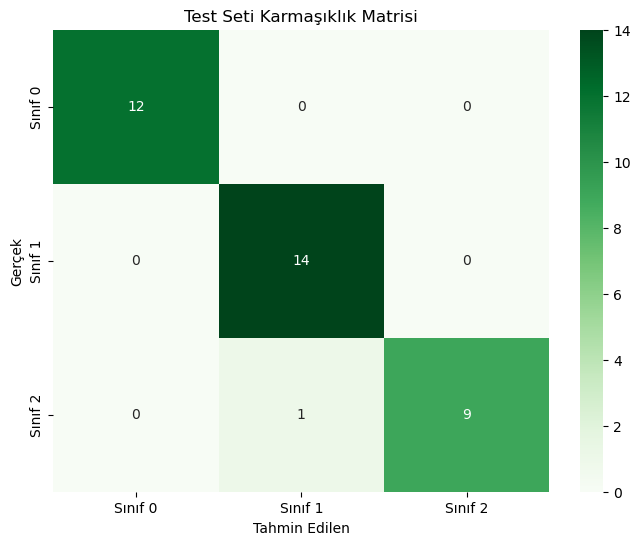

In [59]:
# En iyi modeli test verisiyle çalıştıralım
# Not: Modeli tekrar eğitmemize gerek yok, hafızadaki 'model' değişkeni LDA+LR ise devam edebiliriz.
# Garanti olması için tekrar tanımlayıp eğitelim:
best_model = LogisticRegression(max_iter=1000, random_state=42)
best_model.fit(X_train_lda, y_train)

y_test_pred = best_model.predict(X_test_lda)
y_test_probs = best_model.predict_proba(X_test_lda)

# 9.1 Performans Metrikleri (Classification Report)
print("--- TEST SETİ PERFORMANS RAPORU ---")
print(classification_report(y_test, y_test_pred))

# Çok sınıflı ROC-AUC (ovr: One-vs-Rest)
test_roc_auc = roc_auc_score(y_test, y_test_probs, multi_class='ovr')
print(f"\nTest Seti ROC-AUC Skoru: {test_roc_auc:.4f}")

# 9.2 Confusion Matrix (Heatmap)
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['Sınıf 0', 'Sınıf 1', 'Sınıf 2'], 
            yticklabels=['Sınıf 0', 'Sınıf 1', 'Sınıf 2'])
plt.title('Test Seti Karmaşıklık Matrisi')
plt.xlabel('Tahmin Edilen')
plt.ylabel('Gerçek')
plt.show()

YORUM 9

En iyi model: LDA (Linear Discriminant Analysis) verisi ile eğitilmiş Logistic Regresyon modeli. LDA veriyi doğrusal olarak ayrıştırır. Lojistik regresyon da doğrusal bir sınıflandırıcıdır. Ayrıca eğitimde tam uyum sağladı. Bu nedenle diğer karmaşık ve bilgisayarı yoracak yapıdaki sınıflandırıcılara ihtiyaç duyulmamaktadır. Ayrıca hem basit hem de daha katı bir model olduğu için overfitting riski de düşüktür. Wine veri seti için en uygun modeldir.

Modelimiz test verisi üzerinde %97' lik accuracy oranı göstermiştir. Bu beklenen sonuç modelin veri seti üzerinde eğtimi 1.0 lık bir oranla tamamladıktan sonra alınan doğru bir orandır. Modelimiz başka verilerle karşılaştığında doğru tahminde bulunacaktır kesinliğini bize vermiştir.

HeatMap haritasına baktığımızda modelimiz sadece 1 tane veriyi hatalı olarak sınıf 1 olarak tahmin etmiş. ROC-AUC değerimizin 0.9978 olması, sınıfları birbirinden ayırt ederek doğru tahminler vermeye çalıştığını göstermektedir. 

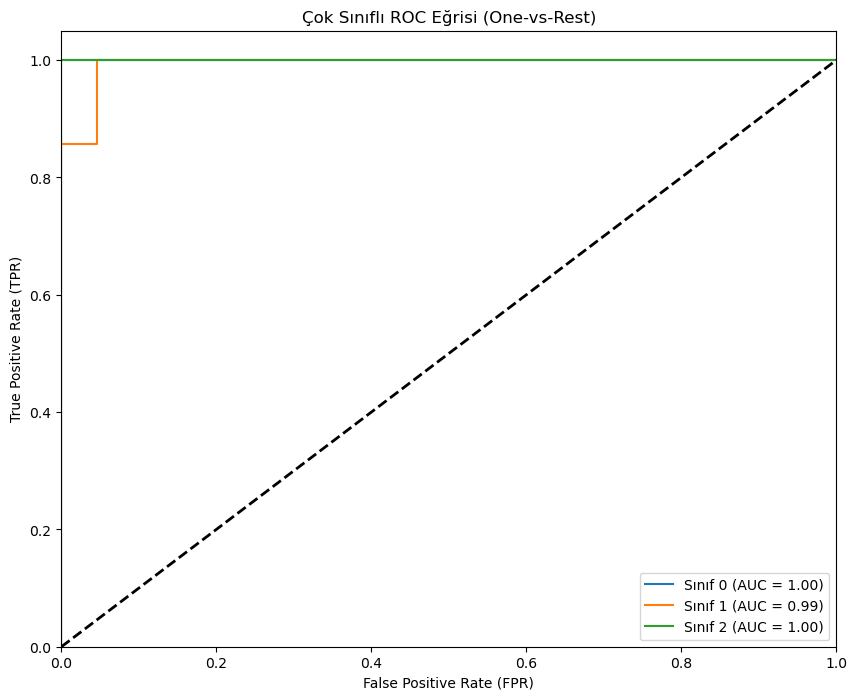

In [ ]:
# Etiketleri binarize edelim (0,1,2 -> [1,0,0], [0,1,0], [0,0,1])
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
n_classes = 3

plt.figure(figsize=(10, 8))

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_test_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Sınıf {i} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Çok Sınıflı ROC Eğrisi (One-vs-Rest)')
plt.legend(loc="lower right")
plt.show()

YORUM 9

Sınıf 0 ve Sınıf 2 için AUC değerleri 1.0 değerine sahip. Yani modelimizin bu 2 sınıf için tahmin olasılığı sıfıra yakın. Sınıf 1' e ait turuncu çizgi bu sınıf için yapılan hatalı tahmini göstermektedir. Bu, modelimizin Sınıf 1' i ayırt ederken küçük bir belirsizlik yaşadığını ama genelde stabil davrandığını bize göstermektedir. Bu sonuçlar modelimizin şans eseri değil, kimyasal örüntülerden tahmin yaptığının da bir kanıtıdır.

Burada sabit bir threshold değeri kullanmadık. ROC eğrisi sayesinde tüm olası eşik değerleri taranarak en uygunları seçilir. Wine veri setinde sınıflar kimyasal özellikleri ile birbirinden net bir şekilde ayrılmaktadır. Net bir threshold değeri belirtmediğimiz için varsayılan olarak 0.50 eşiği kullanılmıştır. Test setinde hatalı bir sınıflandırma yapılmasının nedeni eşik değerin yetersiz olmasıdır. Özel bir hassasiyet gerektiren durumlarda sınıfın eşik değeri optimiz edilebilir.

SORU 10

10. XAI – SHAP Açıklanabilirlik Analizi (Zorunlu)
Bu bölümde, modellerinizin nasıl karar verdiğini açıklayacaksınız.
10.1 En İyi Validation Modeli için SHAP Analizi
Seçtiğiniz en iyi model için:
•	SHAP Explainer kurulacaktır.
•	summary_plot gösterilecektir.
•	bar_plot (ortalama etki büyüklükleri) çizilecektir.
•	En önemli özellikler yorumlanacaktır.
•	Model performansı ve SHAP önem sıralaması ilişkisi tartışılacaktır.
10.2 PCA ve LDA Temsilleri için SHAP Karşılaştırması 
•	PCA ile indirgenmiş veride SHAP analizi
•	LDA ile indirgenmiş veride SHAP analizi
Sınıfların hangi bileşenlerden etkilendiği tartışın.


--- SHAP Summary Plot ---


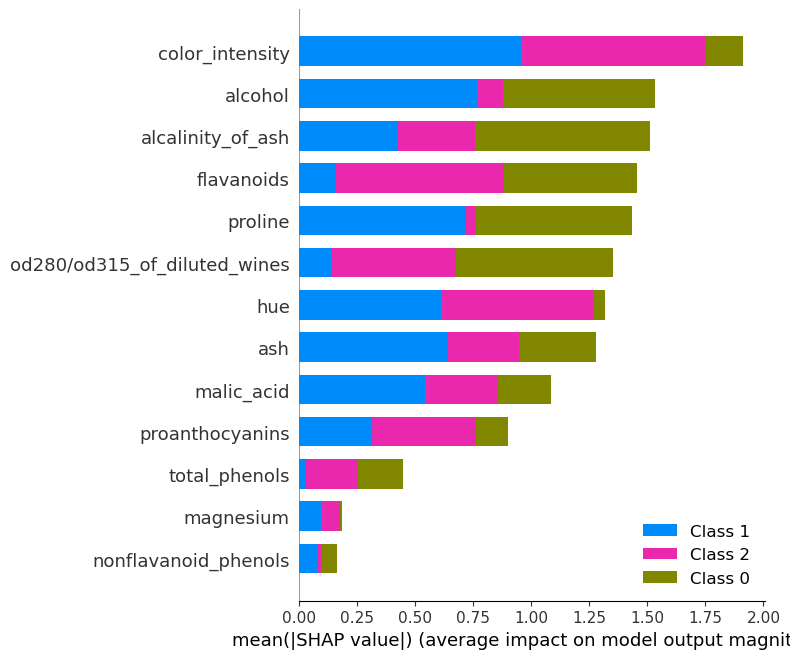

--- SHAP Bar Plot ---
--- SHAP Bar Plot Sınıf 0 ---


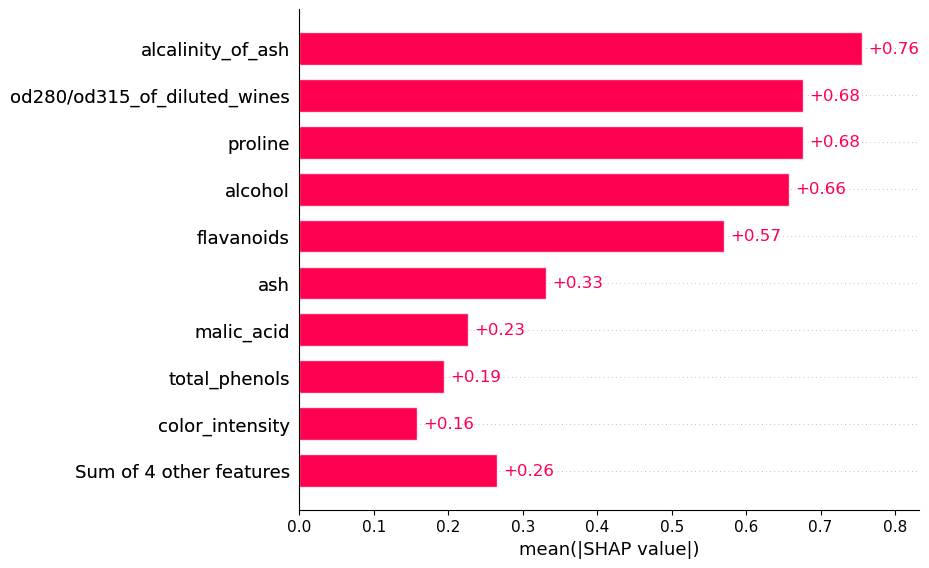

--- SHAP Bar Plot Sınıf 1 ---


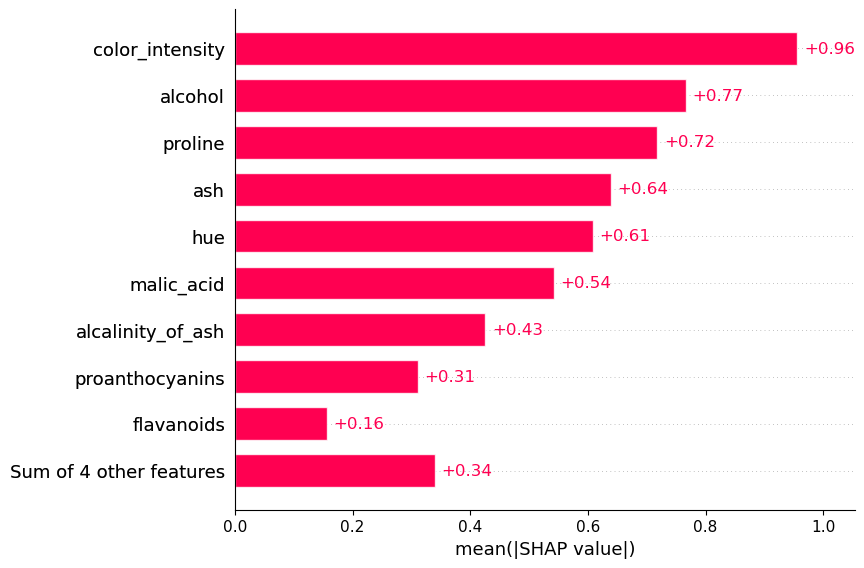

--- SHAP Bar Plot Sınıf 2 ---


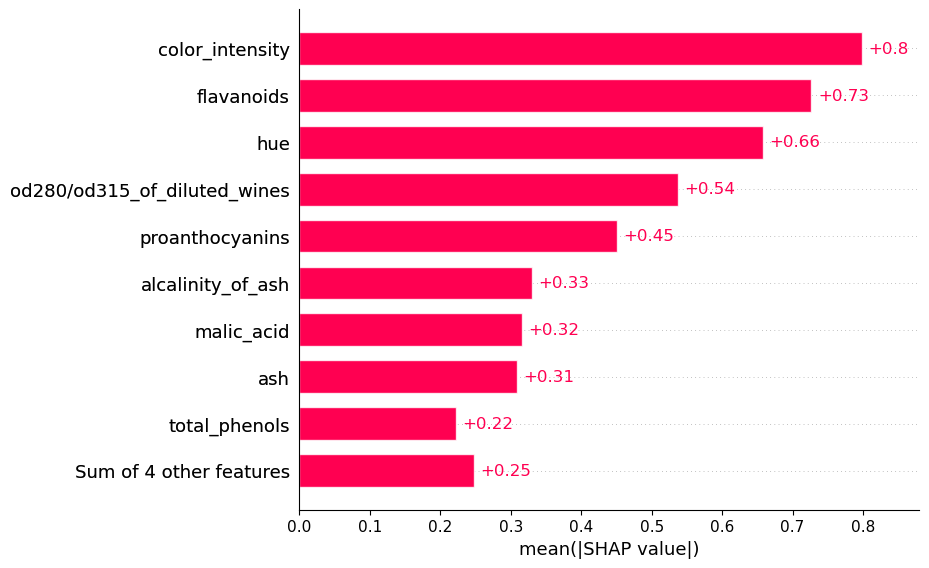

In [68]:
# 1. Önce Ham (Scaled) veriyle çalışan modeli "best_model_scaled" adıyla eğitelim
best_model_scaled = LogisticRegression(max_iter=1000, random_state=42)
best_model_scaled.fit(X_train_scaled, y_train)

# 2. Şimdi SHAP Explainer'ı kurabilirsin
# (wine.feature_names yerine X_train_scaled'in sütun isimlerini de kullanabilirsin)
explainer = shap.Explainer(best_model_scaled, X_train_scaled, feature_names=wine_data.feature_names)
shap_values = explainer(X_val_scaled)

# 3. Summary Plot
print("--- SHAP Summary Plot ---")
shap.summary_plot(shap_values, X_val_scaled, feature_names=wine_data.feature_names)

# 4. Bar Plot
print("--- SHAP Bar Plot ---")
# Sınıf 0 için bar plot (0: Sınıf 0, 1: Sınıf 1, 2: Sınıf 2)
print("--- SHAP Bar Plot Sınıf 0 ---")
shap.plots.bar(shap_values[:, :, 0])
print("--- SHAP Bar Plot Sınıf 1 ---")
shap.plots.bar(shap_values[:, :, 1])
print("--- SHAP Bar Plot Sınıf 2 ---")
shap.plots.bar(shap_values[:, :, 2])

YORUM 10

Color Intensity, Sınıf 1 (Class 1) ve Sınıf 2 (Class 2) için ayırt edici bir özelliktir. Alcohol, Sınıf 0 (Class 0) için etkisi diğer sınıflara oranla daha yüksektir. Alcalinity of Ash ve Flavanoids özellikleri ise modelimizin sınıfları birbirinden ayırmak için kullandığı kimyasal belirleyicilerdir. Sınıf 0' ın belirlenmesinde Alcohol ve Proline' nın etkisi büyüktür. Sınıf 1' in kimliğini belirleyenler ise Color Intensity ve Hue özellikleridir. Sınıf 2' nın tahmin edilmesinde Flavanoids ve Proanthocyanins kimyasalları ön plandadır.

SHAP Summary Plot grafiğindeki çubukların uzunluklarına bakarak, SHAP değerlerinin 1.50-2.00 seviyelerine kadar çıktığı görülmektedir.Bu yüksek etki değerleri, özelliklerin sınıflar arasında belirleyici bir etkiye sahip olduğunu, overfitting yapmadığını göstermektedir.

--- 10.2.1 PCA Temsili SHAP Analizi ---


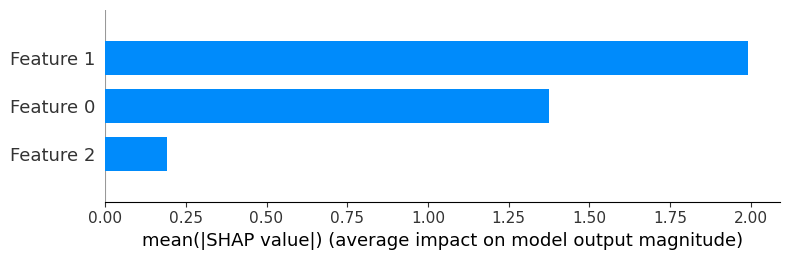


--- 10.2.2 LDA Temsili SHAP Analizi ---


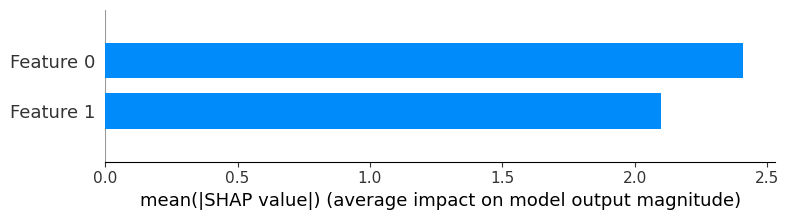

In [70]:
# --- 10.2.1 PCA Temsili SHAP ---
print("--- 10.2.1 PCA Temsili SHAP Analizi ---")
model_pca = LogisticRegression(max_iter=1000, random_state=42).fit(X_train_pca, y_train)
explainer_pca = shap.Explainer(model_pca, X_train_pca)
shap_values_pca = explainer_pca(X_val_pca)

# Hata Çözümü: Sınıfların ortalamasını Explanation nesnesini bozmadan alıyoruz
# Eğer 3 sınıf varsa (0,1,2), bunlar üzerinde mutlak değer ortalaması alalım
if len(shap_values_pca.shape) == 3: # Çok sınıflı çıktıysa
    values_pca = np.abs(shap_values_pca.values).mean(axis=2).mean(axis=0)
    # Yeni bir bar plot için basit görselleştirme:
    shap.summary_plot(np.abs(shap_values_pca.values).mean(axis=2), X_val_pca, plot_type="bar")
else:
    shap.plots.bar(shap_values_pca)

# --- 10.2.2 LDA Temsili SHAP ---
print("\n--- 10.2.2 LDA Temsili SHAP Analizi ---")
model_lda = LogisticRegression(max_iter=1000, random_state=42).fit(X_train_lda, y_train)
explainer_lda = shap.Explainer(model_lda, X_train_lda)
shap_values_lda = explainer_lda(X_val_lda)

if len(shap_values_lda.shape) == 3:
    shap.summary_plot(np.abs(shap_values_lda.values).mean(axis=2), X_val_lda, plot_type="bar")
else:
    shap.plots.bar(shap_values_lda)

YORUM 10

PCA grafiğinde Feature 0 ve Feature 1 arasında dengeli bir dağılım var. PCA, sınıfları bilmeden en büyük değişimi bulmaya çalışır. Sınıflar sadece ilk bileşenle tam olarak açıklanamaz ikinci bir bileşene daha ihtiyaç duyar. LDA grafiğinde ise veriyi, sınıfları en iyi ayıracak şekilde bir çizgi üzerinde belirlediği için, Feature 0 üzerinden sınıfları ayırt eder. PCA model verinin yapısına odaklanırken, LDA ayırıcı özelliğe odaklanır. Bu da LDA yı ön plana çıkarır.